<a href="https://colab.research.google.com/github/Dmitze/Dmitze/blob/main/%D0%94%D0%BC%D0%B8%D1%82%D1%80%D0%BE_%D0%A8%D0%B8%D0%B2%D0%B0%D1%87%D0%BE%D0%B2_%D0%94%D0%97_%D0%A2%D0%B5%D0%BC%D0%B0_9_Markov_chain_FrozenLake_PolicyIteration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# встановлення потрібних бібліотек
!pip install gymnasium matplotlib numpy -q

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Крок 1 — Завантажуємо середовище

In [3]:
# frozenLake — сітка 4x4: стартова клітинка S, крига F, дірки H, ціль G
# is_slippery=True за замовчуванням — агент не завжди рухається в потрібну сторону
env = gym.make('FrozenLake-v1')
env.reset()

n_states  = env.observation_space.n   # 16
n_actions = env.action_space.n        # 4: 0=ліво 1=вниз 2=право 3=вгору

print(f"Станів: {n_states}, Дій: {n_actions}")

Станів: 16, Дій: 4


## Крок 2 — `compute_value_function()`

Функція оцінює, наскільки «вигідний» кожен стан при заданій політиці.  
Ітеративно застосовуємо рівняння Беллмана поки значення не перестануть суттєво змінюватись.

In [10]:
def compute_value_function(policy, env, gamma=0.99, theta=1e-6):
    """
    Оцінка функції цінності V(s) для фіксованої політики.
    gamma — дисконт майбутніх нагород, theta — поріг зупинки.
    """
    V = np.zeros(env.observation_space.n)

    while True:
        delta = 0
        for s in range(env.observation_space.n):
            v_old = V[s]
            a = policy[s]
            V[s] = sum(
                prob * (r + gamma * V[s_next])
                for prob, s_next, r, _ in env.unwrapped.P[s][a]
            )

            delta = max(delta, abs(v_old - V[s]))

        if delta < theta:
            break

    return V

## Крок 3 — `policy_iteration()`

Алгоритм чергує два кроки:
1. **Оцінка** — рахуємо V(s) для поточної політики
2. **Покращення** — в кожному стані обираємо дію з максимальним Q-значенням

Повторюємо поки політика не стабілізується.

In [5]:
def policy_iteration(env, gamma=0.99, theta=1e-6):
    """
    Знаходить оптимальну політику методом ітерацій за політикою.
    Повертає (оптимальну_політику, функцію_цінності).
    """
    n_states  = env.observation_space.n
    n_actions = env.action_space.n

    # стартова політика — скрізь дія 0 (рух ліво)
    policy = np.zeros(n_states, dtype=int)

    iteration = 0
    while True:
        iteration += 1

        # крок оцінки
        V = compute_value_function(policy, env, gamma, theta)

        # крок покращення
        stable = True
        for s in range(n_states):
            old_a = policy[s]

            # Q(s,a) для кожної дії
            q = [
                sum(prob * (r + gamma * V[s_next])
                    for prob, s_next, r, _ in env.unwrapped.P[s][a])
                for a in range(n_actions)
            ]
            policy[s] = int(np.argmax(q))

            if old_a != policy[s]:
                stable = False

        print(f"Ітерація {iteration}: {'готово ✓' if stable else 'продовжуємо...'}")

        if stable:
            break

    return policy, V

In [6]:
# запускаємо і дивимось результат
optimal_policy, optimal_V = policy_iteration(env)

action_map = {0: 'ЛІВО', 1: 'ВНИЗ', 2: 'ПРАВО', 3: 'ВГОРУ'}

print("\nОптимальна політика (4x4 сітка):")
grid = np.array([action_map[a] for a in optimal_policy]).reshape(4, 4)
for row in grid:
    print(" ", row)

print("\nФункція цінності V(s):")
print(np.round(optimal_V.reshape(4, 4), 4))

Ітерація 1: продовжуємо...
Ітерація 2: продовжуємо...
Ітерація 3: продовжуємо...
Ітерація 4: продовжуємо...
Ітерація 5: продовжуємо...
Ітерація 6: продовжуємо...
Ітерація 7: готово ✓

Оптимальна політика (4x4 сітка):
  ['ЛІВО' 'ВГОРУ' 'ВГОРУ' 'ВГОРУ']
  ['ЛІВО' 'ЛІВО' 'ЛІВО' 'ЛІВО']
  ['ВГОРУ' 'ВНИЗ' 'ЛІВО' 'ЛІВО']
  ['ЛІВО' 'ПРАВО' 'ВНИЗ' 'ЛІВО']

Функція цінності V(s):
[[0.542  0.4988 0.4707 0.4568]
 [0.5584 0.     0.3583 0.    ]
 [0.5918 0.6431 0.6152 0.    ]
 [0.     0.7417 0.8628 0.    ]]


## Крок 4 — `show_render()` — візуалізація оптимальної політики

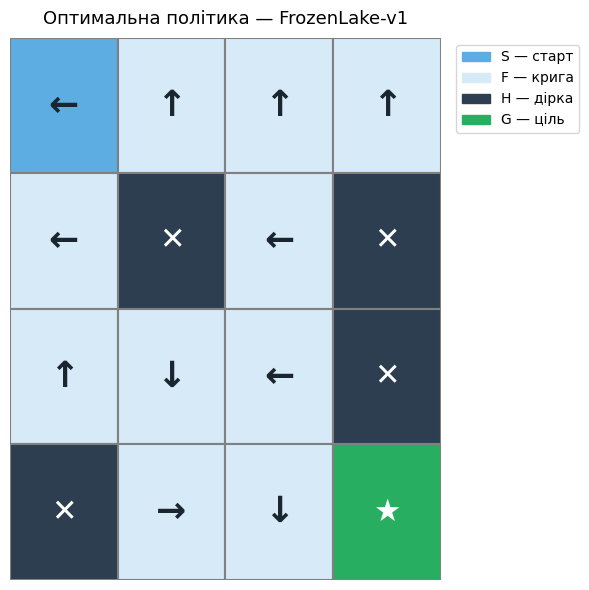

In [7]:
def show_render(policy):
    """Малює карту FrozenLake зі стрілками оптимальних дій."""

    arrows = {0: '←', 1: '↓', 2: '→', 3: '↑'}

    # стандартна карта
    lake = [
        ['S', 'F', 'F', 'F'],
        ['F', 'H', 'F', 'H'],
        ['F', 'F', 'F', 'H'],
        ['H', 'F', 'F', 'G']
    ]

    colors = {'S': '#5dade2', 'F': '#d6eaf8', 'H': '#2c3e50', 'G': '#27ae60'}

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 4)
    ax.axis('off')
    ax.set_title('Оптимальна політика — FrozenLake-v1', fontsize=13, pad=10)

    for row in range(4):
        for col in range(4):
            s    = row * 4 + col
            tile = lake[row][col]

            rect = plt.Rectangle([col, 3 - row], 1, 1,
                                  facecolor=colors[tile], edgecolor='gray', lw=1.5)
            ax.add_patch(rect)

            if tile == 'H':
                ax.text(col + 0.5, 3 - row + 0.5, '✕',
                        ha='center', va='center', fontsize=22, color='white', fontweight='bold')
            elif tile == 'G':
                ax.text(col + 0.5, 3 - row + 0.5, '★',
                        ha='center', va='center', fontsize=22, color='white', fontweight='bold')
            else:
                ax.text(col + 0.5, 3 - row + 0.5, arrows[policy[s]],
                        ha='center', va='center', fontsize=26, color='#1a252f', fontweight='bold')

    # легенда
    legend = [
        mpatches.Patch(color=colors['S'], label='S — старт'),
        mpatches.Patch(color=colors['F'], label='F — крига'),
        mpatches.Patch(color=colors['H'], label='H — дірка'),
        mpatches.Patch(color=colors['G'], label='G — ціль'),
    ]
    ax.legend(handles=legend, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)

    plt.tight_layout()
    plt.show()


show_render(optimal_policy)

## Висновок

У цій роботі я реалізував алгоритм **Policy Iteration** для задачі навчання з підкріпленням на середовищі `FrozenLake-v1`.                 

**Policy Iteration** гарантовано знаходить оптимальну політику завдяки властивості Маркова — майбутній стан залежить лише від поточного, тому рівняння Беллмана коректно оцінює кожен стан незалежно від передісторії.